Atividade Ciência de Dados - 23/02/2026

**INFORMAÇÕES DO DATASET**

Nome do Dataset: Série Histórica de Preços de Combustíveis e de GLP.

Órgão Responsável: Agência Nacional do Petróleo, Gás Natural e Biocombustíveis (ANP).

Finalidade: Monitorar os preços praticados pelos revendedores de combustíveis automotivos em todo o território nacional, servindo como base para estudos econômicos e defesa do consumidor.

Periodicidade: Semestral (neste caso, referente ao início de 2025).

 Link para o DataSet = https://dados.gov.br/dados/conjuntos-dados/serie-historica-de-precos-de-combustiveis-e-de-glp

In [8]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

caminho = '/content/drive/MyDrive/glp-2025-01.csv'
df = pd.read_csv(caminho, sep=';', encoding='latin-1')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# 1. Garante que estamos pegando apenas o que é texto e limpando
# Remove espaços em branco e troca a vírgula pelo ponto
df['Valor de Venda'] = df['Valor de Venda'].astype(str).str.replace(',', '.')

# 2. Converte para número (float)
# O errors='coerce' serve para transformar qualquer texto estranho em "vazio" (NaN)
# em vez de travar o seu código com erro
df['Valor de Venda'] = pd.to_numeric(df['Valor de Venda'], errors='coerce')

# 3. Remove linhas que ficaram vazias após a conversão (opcional, mas recomendado)
df = df.dropna(subset=['Valor de Venda'])

# Agora você pode rodar as estatísticas que vai funcionar!
coluna = df['Valor de Venda']
print(f"Média: {coluna.mean():.2f}")
print(f"Mediana: {coluna.median():.2f}")

Média: 108.71
Mediana: 109.90


In [7]:
coluna = df['Valor de Venda']

print(f"Média: {coluna.mean():.2f}")
print(f"Mediana: {coluna.median():.2f}")
print(f"Moda: {coluna.mode()[0]:.2f}")
print(f"Mínimo: {coluna.min():.2f}")
print(f"Máximo: {coluna.max():.2f}")
print(f"Desvio Padrão: {coluna.std():.2f}")
print(f"Variância: {coluna.var():.2f}")

# Quartis e IQR
q1 = coluna.quantile(0.25)
q3 = coluna.quantile(0.75)
iqr = q3 - q1

print(f"1º Quartil (Q1): {q1:.2f}")
print(f"3º Quartil (Q3): {q3:.2f}")
print(f"Intervalo Interquartil (IQR): {iqr:.2f}")

Média: 108.71
Mediana: 109.90
Moda: 110.00
Mínimo: 74.99
Máximo: 170.00
Desvio Padrão: 12.35
Variância: 152.63
1º Quartil (Q1): 99.99
3º Quartil (Q3): 115.00
Intervalo Interquartil (IQR): 15.01


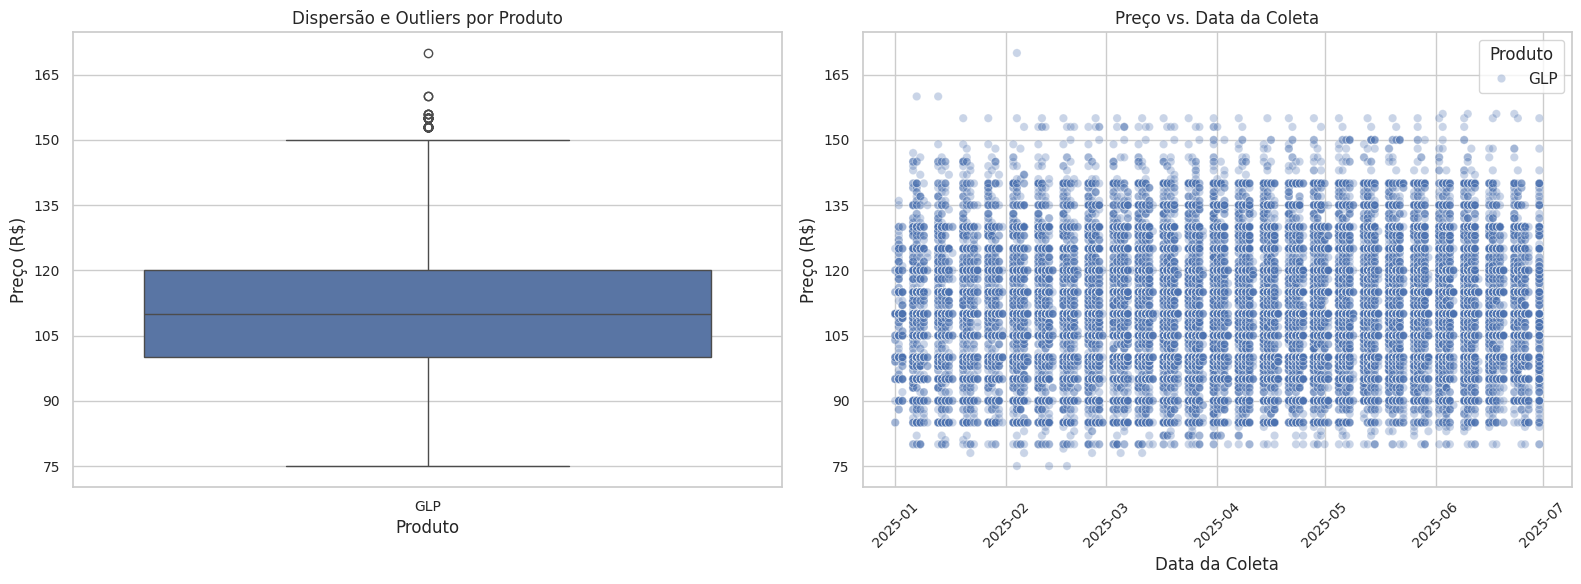

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 1. Configuração de Estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# --- GRÁFICO 1: BOXPLOT (Lado Esquerdo) ---
ax1 = plt.subplot(1, 2, 1)
# O 'hue' separa por cores e o 'legend=False' evita o erro que você teve
sns.boxplot(data=df, x='Produto', y='Valor de Venda', hue='Produto', legend=False)
ax1.set_title('Dispersão e Outliers por Produto')
ax1.set_ylabel('Preço (R$)')

# --- GRÁFICO 2: DISPERSÃO (Lado Direito) ---
ax2 = plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Data da Coleta', y='Valor de Venda', hue='Produto', alpha=0.3)
ax2.set_title('Preço vs. Data da Coleta')
ax2.set_ylabel('Preço (R$)')
plt.xticks(rotation=45)

# --- AJUSTE DE LEGIBILIDADE (O PULO DO GATO) ---
for ax in [ax1, ax2]:
    # Isso aqui limpa a bagunça do eixo Y (mostra no máximo 10 valores)
    ax.yaxis.set_major_locator(plt.MaxNLocator(10))
    # Ajusta o tamanho da fonte para não embolar
    ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()
plt.show()